In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("HR_Analytics.csv")

In [4]:
df.head()

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


In [5]:
num_of_employees = df.shape[0]

In [6]:
num_of_employees

1480

In [7]:
attrition_count = df[df['Attrition']=="Yes"].shape[0]

In [8]:
attrition_count

238

In [9]:
attrition_rate = (attrition_count/num_of_employees)*100

In [10]:
attrition_rate

16.08108108108108

In [11]:
avg_age = float(df['Age'].mean())

In [12]:
avg_age

36.917567567567566

In [13]:
avg_age = round(avg_age,2)
avg_age

36.92

In [14]:
avg_salary = round(float(df['MonthlyIncome'].mean()),2)
avg_salary

6504.99

In [15]:
avg_tenure = round(float(df['YearsAtCompany'].mean()),2)
avg_tenure

7.01

In [16]:

kpis = {
    "Number of Employees" : [num_of_employees],
    "Attrition Count" : [attrition_count],
    "Attrition Rate" : [attrition_rate],
    "Average Age" : [avg_age],
    "Average Salary" : [avg_salary],
    "Average Tenure" : [avg_tenure]
}

Kpidf = pd.DataFrame(kpis)

In [17]:
Kpidf

,Number of Employees,Attrition Count,Attrition Rate,Average Age,Average Salary,Average Tenure
0,1480,238,16.081081,36.92,6504.99,7.01


In [18]:
df.set_index("EducationField")["Attrition"].value_counts()

Attrition
No     1242
Yes     238
Name: count, dtype: int64

In [19]:
df.groupby(['EducationField', 'Attrition'])['Attrition'].count().reset_index(name='Count')

,EducationField,Attrition,Count
0,Human Resources,No,20
1,Human Resources,Yes,7
2,Life Sciences,No,518
3,Life Sciences,Yes,89
4,Marketing,No,125
5,Marketing,Yes,36
6,Medical,No,407
7,Medical,Yes,63
8,Other,No,72
9,Other,Yes,11


In [20]:
attrition_by_education = df.groupby(['EducationField', 'Attrition'])['Attrition'].count().reset_index(name='Count')

In [21]:
education_fields = attrition_by_education['EducationField'].unique()


In [22]:
attrition_counts = []


In [23]:
for field in education_fields:
    attrition_count = attrition_by_education[(attrition_by_education['EducationField'] == field) & (attrition_by_education['Attrition'] == 'Yes')]['Count'].values[0]
    attrition_counts.append(attrition_count)


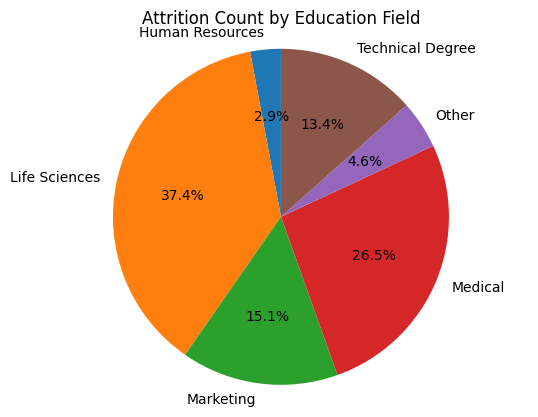

In [24]:
plt.pie(attrition_counts, labels=education_fields, autopct='%1.1f%%', startangle=90)
plt.title('Attrition Count by Education Field')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [25]:
attrition_by_education['EducationField'].unique()

array(['Human Resources', 'Life Sciences', 'Marketing', 'Medical',
       'Other', 'Technical Degree'], dtype=object)

In [26]:
attrition_by_gender = df.groupby(['Gender', 'Attrition'])['Attrition'].count().reset_index(name='Count')

In [27]:
gender_fields = attrition_by_gender['Gender'].unique()


In [28]:
attrition_counts = []

In [29]:
for field in gender_fields:
    attrition_count = attrition_by_gender[(attrition_by_gender['Gender'] == field) & (attrition_by_gender['Attrition'] == 'Yes')]['Count'].values[0]
    attrition_counts.append(attrition_count)


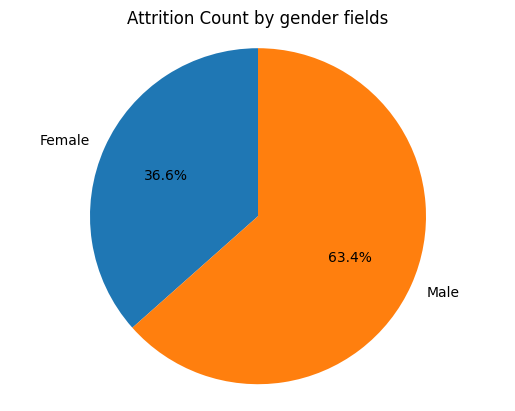

In [30]:
plt.pie(attrition_counts, labels=gender_fields, autopct='%1.1f%%', startangle=90)
plt.title('Attrition Count by gender fields')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [31]:
attrition_by_gender = df.groupby(['Gender', 'Attrition'])['Attrition'].count().reset_index(name='Count')
attrition_by_gender

,Gender,Attrition,Count
0,Female,No,504
1,Female,Yes,87
2,Male,No,738
3,Male,Yes,151


In [32]:
gender_fields = attrition_by_gender['Gender'].unique()
gender_fields

array(['Female', 'Male'], dtype=object)

In [33]:
attrition_counts = []

In [34]:
for gender in gender_fields:
    count = attrition_by_gender[
        (attrition_by_gender['Gender'] == gender) &
        (attrition_by_gender['Attrition'] == 'Yes')
    ]['Count'].values[0]

    attrition_counts.append(count)

print(attrition_counts)

[np.int64(87), np.int64(151)]


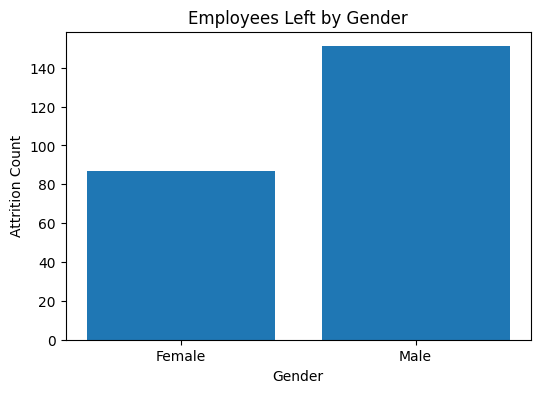

In [35]:
plt.figure(figsize=(6,4))
plt.bar(gender_fields, attrition_counts)

plt.xlabel("Gender")
plt.ylabel("Attrition Count")
plt.title("Employees Left by Gender")
plt.show()

In [36]:
print(gender_fields)
print(attrition_counts)
print(len(gender_fields))
print(len(attrition_counts))

['Female' 'Male']
[np.int64(87), np.int64(151)]
2
2


In [37]:
attrition_counts = []

In [38]:
attrition_counts = []

for gender in gender_fields:
    count = attrition_by_gender[
        (attrition_by_gender['Gender'] == gender) &
        (attrition_by_gender['Attrition'] == 'Yes')
    ]['Count'].values[0]

    attrition_counts.append(count)

print(attrition_counts)

[np.int64(87), np.int64(151)]


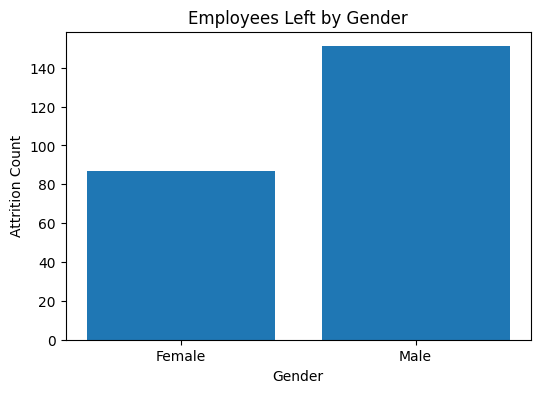

In [39]:
plt.figure(figsize=(6,4))
plt.bar(gender_fields, attrition_counts)

plt.xlabel("Gender")
plt.ylabel("Attrition Count")
plt.title("Employees Left by Gender")
plt.show()

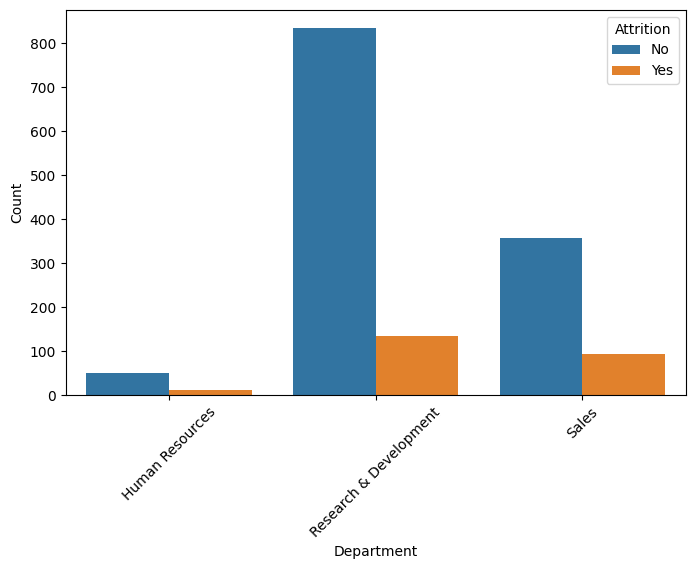

In [40]:
dept = df.groupby(['Department','Attrition']).size().reset_index(name='Count')

plt.figure(figsize=(8,5))
sns.barplot(data=dept, x='Department', y='Count', hue='Attrition')
plt.xticks(rotation=45)
plt.show()

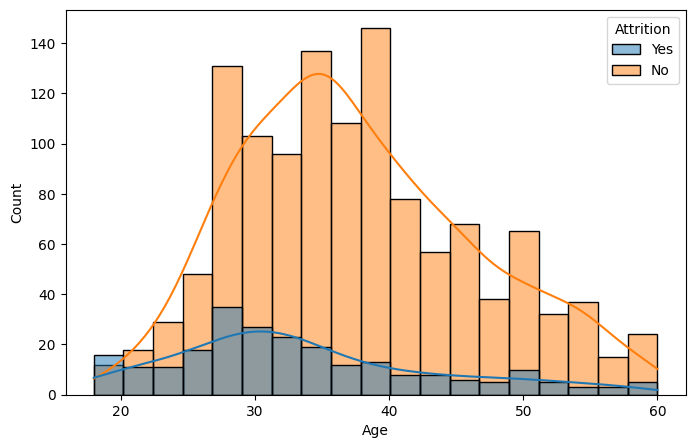

In [41]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Attrition', kde=True)
plt.show()

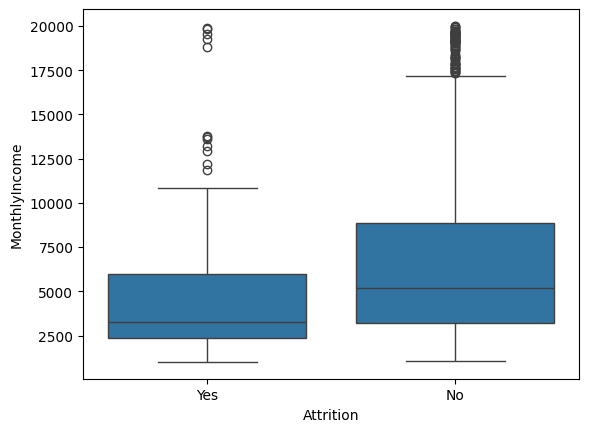

In [42]:
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')
plt.show()

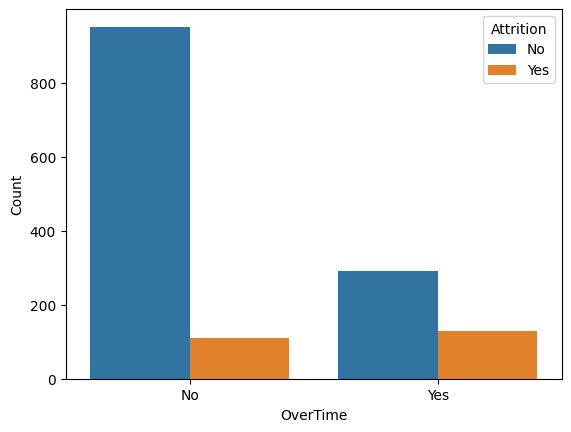

In [43]:
overtime = df.groupby(['OverTime','Attrition']).size().reset_index(name='Count')

sns.barplot(data=overtime, x='OverTime', y='Count', hue='Attrition')
plt.show()

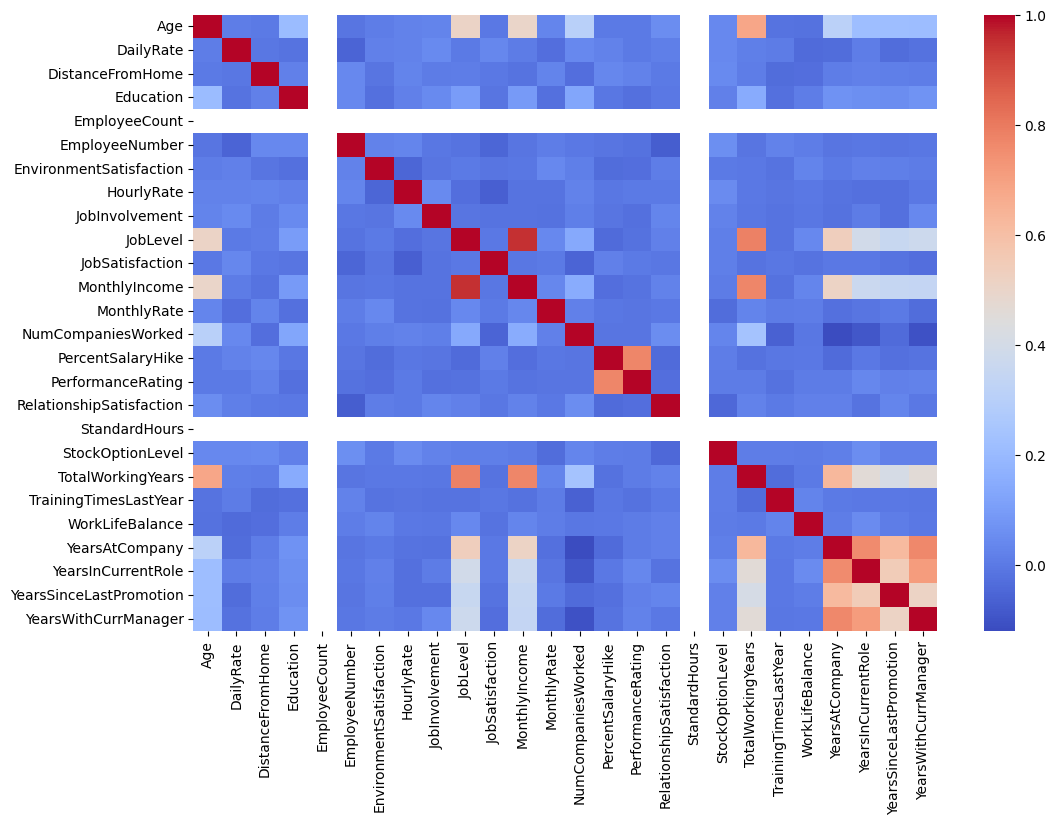

In [45]:
numeric = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric.corr(), cmap='coolwarm')
plt.show()